# Lab: Building an Interactive Dashboard

In the lecture, we built a dashboard one piece at a time. In this lab, you will bring together the analysis workflow, Plotly figures, and Dash components to create an interactive dashboard using a dataset of your choosing.

Your dashboard should help a specific audience answer a focused question. The goal is not to fit every possible chart onto one page. Select a small set of related evidence, organize it clearly, and give the user one useful way to interact with it.



## Learning goals

By the end of this lab, you should be able to:

- use the reproducible analysis workflow to plan a dashboard;
- prepare and check data before displaying it;
- create Plotly figures that answer related questions;
- organize text, controls, and figures in a Dash layout;
- connect an interactive control to figures with a callback; and
- explain the conclusion and limitations of a dashboard.



## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding every part of the submitted work, testing the dashboard, citing the dataset, and checking that the evidence supports your conclusion. Do not submit private, confidential, or personally identifying data to an AI system.



## Assignment requirements

Choose a dataset that supports a meaningful comparison. It should contain:

- enough observations to reveal a pattern rather than a few isolated cases;
- at least one categorical feature that can be used as an interactive filter or comparison;
- at least two additional useful features, which may be categorical, quantitative, temporal, spatial, or text-derived; and
- enough documentation for you to explain what the records and selected features represent.

The completed dashboard must contain:

- a descriptive title and a short explanation of its purpose;
- at least two related Plotly figures;
- at least one dropdown menu or radio-button control;
- at least one callback that updates both figures;
- human-readable titles, labels, categories, and colors;
- stable axes or category orders when changing them would make comparisons misleading; and
- a brief conclusion and limitation displayed on the page.



# Step 1: Question



## 1. Identify the audience

A dashboard should be designed for someone. Identify a realistic audience and explain what decision, judgment, or understanding the dashboard could support.



**Who is the intended audience, and why would this evidence be useful to them?** The intended audience is bike sharing operations staff in Seoul. This evidence could help them understand when bike demand is highest and how demand changes across different seasons and temperatures.


## 2. State the research question

Write one focused question that your two figures will help answer. The question should name the main features or groups being compared.



**What question will the dashboard answer?** How do hourly bike rental patterns and the relationship between temperature and rental demand differ by season in Seoul?



## 3. Make a prediction



**What pattern do you expect to find, and what informed that prediction?** I expect bike rentals to be higher during warmer seasons and lower during winter. I also expect rental demand to be higher during common commuting hours.


# Step 2: Data



## 4. Import the libraries

Import Pandas, Plotly Express, and the Dash objects used in the lecture: `Dash`, `dcc`, `html`, `Input`, and `Output`.



In [1]:
import pandas as pd
import plotly.express as px

from dash import Dash, dcc, html, Input, Output

## 5. Document the dataset

Give the dataset title, its creator or publisher, a working link or citation, the time period represented, and any relevant collection or sampling information.



**Where did the data come from, and what does its documentation tell you about how it was collected?** The dataset is called Seoul Bike Sharing Demand and comes from the UCI Machine Learning Repository. It contains 8,760 hourly records from the Seoul Bike Sharing System from December 1, 2017 through November 30, 2018. The data includes bike rental counts along with weather, season, holiday, and date information. It was collected to study hourly bike demand and help make rental bikes available when they are needed. The dataset has no missing values.
Link: https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand



## 6. Read the data

Read the dataset into a Pandas DataFrame. Give the DataFrame a short, descriptive name.



In [2]:
bikes = pd.read_csv(
    "data/SeoulBikeData.csv",
    encoding="unicode_escape"
)

## 7. Preview and inspect the DataFrame

Display the first five rows, last five rows, stored data types, and missing-value counts.



In [3]:
display(bikes.head())
display(bikes.tail())

bikes.info()

bikes.isnull().sum()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,30/11/2018,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

**Complete the table for every feature you expect to use. Add or remove rows as needed.**

| Feature | What it represents | Data storage type | Feature type | Missing values | Dashboard role |
|---|---|---|---|---:|---|
| Rented Bike Count | Number of bikes rented during the hour | int64 | Quantitative | 0 | Main value being analyzed |
| Hour | Hour of the day 0-23 | int64 | Quantitative | 0 | Used for hourly rental figure |
| Temperature(C) | Temperature during the hour | float64 | Quantitative | 0 | Used to compare temperature with rentals |
| Seasons | Season of the year | str | Categorical | 0 | Interactive dropdown control |
| Functioning Day | Whether the bike system was operating | str | Categorical | 0 | Used to remove non functioning days |



**What does one row of the original dataset represent?** One row represents one hour of bike sharing activity in Seoul, including the number of bikes rented and the weather and seasonal conditions during that hour.



# Step 3: Operation



## 8. Create the analysis DataFrame

Select the features needed for the dashboard and use `.copy()` to create a DataFrame named `analysis`. Handle missing values in a way that is appropriate for the question. If values need clearer labels or corrected storage types, make those changes here.



In [4]:
analysis = bikes[
    [
        "Rented Bike Count",
        "Hour",
        "Temperature(°C)",
        "Seasons",
        "Functioning Day"
    ]
].copy()

analysis = analysis[
    analysis["Functioning Day"] == "Yes"
].copy()

**How did you handle missing values, and why was that choice appropriate?** There were no missing values in the features I selected, so no rows needed to be removed for missing data. I removed non functioning days because zero rentals during those times would not represent normal bike demand.



## 9. Create any calculated features

If the dashboard needs a calculated category, date component, percentage, rate, or other calculated feature, create it here. If no calculated feature is needed, leave the code cell blank and explain why.



**What calculated feature or cleaned label did you create, and how will it support the dashboard?**

I did not create a calculated feature because the dataset already includes the hour, season, temperature, and bike rental count needed for the dashboard.

## 10. Prepare the control options

Create the labels and values for the dropdown or radio-button control. The visible labels should be understandable to someone who has not seen the original column names.



In [5]:
season_options = [
    {"label": "Winter", "value": "Winter"},
    {"label": "Spring", "value": "Spring"},
    {"label": "Summer", "value": "Summer"},
    {"label": "Autumn", "value": "Autumn"}
]

# Step 4: Check



## 11. Check the prepared data

Display the first rows of `analysis`, its stored data types, missing-value counts, and appropriate summaries or frequency counts for the dashboard features.



In [6]:
display(analysis.head())

print("\nData types:")
print(analysis.dtypes)

print("\nMissing values:")
print(analysis.isnull().sum())

print("\nQuantitative summary:")
display(
    analysis[
        ["Rented Bike Count", "Hour", "Temperature(°C)"]
    ].describe()
)

print("\nSeason counts:")
print(analysis["Seasons"].value_counts())



,Rented Bike Count,Hour,Temperature(°C),Seasons,Functioning Day
0,254,0,-5.2,Winter,Yes
1,204,1,-5.5,Winter,Yes
2,173,2,-6.0,Winter,Yes
3,107,3,-6.2,Winter,Yes
4,78,4,-6.0,Winter,Yes



Data types:
Rented Bike Count      int64
Hour                   int64
Temperature(°C)      float64
Seasons                  str
Functioning Day          str
dtype: object

Missing values:
Rented Bike Count    0
Hour                 0
Temperature(°C)      0
Seasons              0
Functioning Day      0
dtype: int64

Quantitative summary:


,Rented Bike Count,Hour,Temperature(°C)
count,8465.000000,8465.000000,8465.000000
mean,729.156999,11.507029,12.771057
std,642.351166,6.920899,12.104375
min,2.000000,0.000000,-17.800000
25%,214.000000,6.000000,3.000000
50%,542.000000,12.000000,13.500000
75%,1084.000000,18.000000,22.700000
max,3556.000000,23.000000,39.400000



Season counts:
Seasons
Summer    2208
Winter    2160
Spring    2160
Autumn    1937
Name: count, dtype: int64


## 12. Check the interactive groups

Calculate the number of observations available for every control option. Make sure each option returns data and that unexpectedly small groups are understood before building the callback.



In [7]:
print(
    analysis["Seasons"]
    .value_counts()
    .reindex(["Winter", "Spring", "Summer", "Autumn"])
)

Seasons
Winter    2160
Spring    2160
Summer    2208
Autumn    1937
Name: count, dtype: int64


**What did these checks establish about the data that will appear in the dashboard?** The checks showed that all four seasons have a large number of observations and no missing values. This means every dropdown option should have enough data to create both figures and make meaningful comparisons.



# Step 5: Evidence



## 13. Create the first static Plotly figure

Build the first figure before placing it in Dash. Give it a descriptive title and human-readable axis and legend labels.



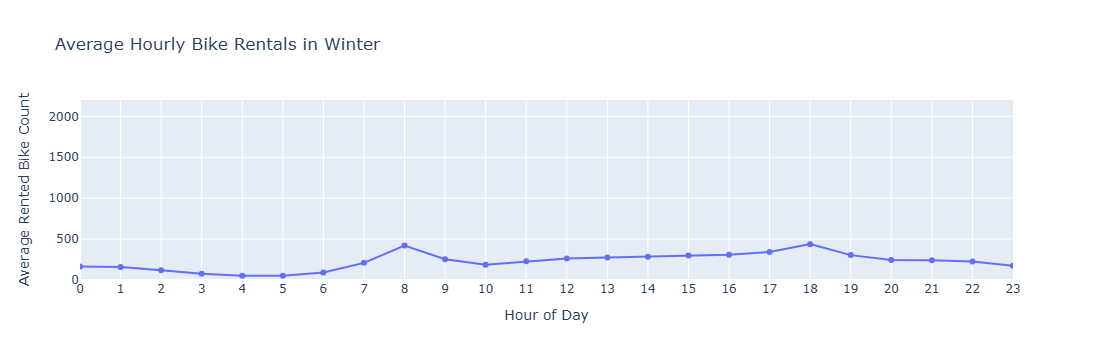

In [8]:
winter = analysis[
    analysis["Seasons"] == "Winter"
]

hourly_winter = (
    winter.groupby("Hour", as_index=False)["Rented Bike Count"]
    .mean()
)

fig1 = px.line(
    hourly_winter,
    x="Hour",
    y="Rented Bike Count",
    markers=True,
    title="Average Hourly Bike Rentals in Winter",
    labels={
        "Hour": "Hour of Day",
        "Rented Bike Count": "Average Rented Bike Count"
    }
)

fig1.update_xaxes(
    tickmode="linear",
    dtick=1,
    range=[0, 23]
)

fig1.update_yaxes(
    range=[0, 2200]
)

fig1.show()



**What evidence should a viewer obtain from the first figure?** The first figure shows how average bike rental demand changes throughout the day. It helps the viewer identify which hours have the highest and lowest rental demand for the selected season.



## 14. Create the second static Plotly figure

The second figure should add different but related evidence rather than repeat the first figure in another style.



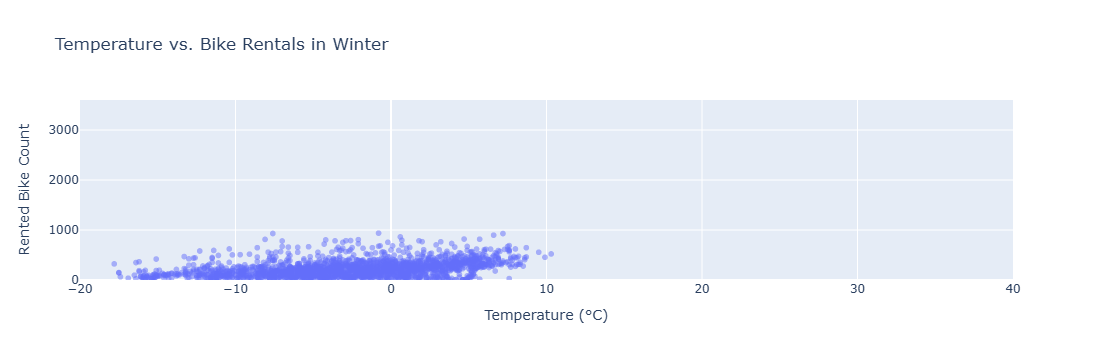

In [9]:
fig2 = px.scatter(
    winter,
    x="Temperature(°C)",
    y="Rented Bike Count",
    title="Temperature vs. Bike Rentals in Winter",
    labels={
        "Temperature(°C)": "Temperature (°C)",
        "Rented Bike Count": "Rented Bike Count"
    },
    opacity=0.5
)

fig2.update_xaxes(
    range=[-20, 40]
)

fig2.update_yaxes(
    range=[0, 3600]
)

fig2.show()


**What does the second figure add to the first figure's evidence?** The second figure shows how bike rental demand changes with temperature. It adds weather-related evidence to the hourly demand pattern shown in the first figure.



## 15. Plan the dashboard



**Complete the dashboard plan before writing the app. Add rows if needed.**

| Component | What it displays or controls | Why it belongs on the dashboard |
|---|---|---|
| Title and introduction | Explains that the dashboard compares bike rental demand by season | Helps the viewer understand the purpose of the dashboard |
| Interactive control | Dropdown menu for Winter, Spring, Summer, and Autumn | Lets the viewer compare the same evidence across seasons |
| First figure | Average bike rentals by hour of day | Shows when bike demand is highest and lowest |
| Second figure | Temperature compared with rented bike count | Shows how rental demand relates to temperature |
| Conclusion and limitation | Summarizes the main pattern and explains an important limitation | Helps the viewer interpret the evidence correctly |



## 16. Create reusable figure code

Write a function that accepts the selected control value, filters or summarizes `analysis`, creates both Plotly figures, and returns the figures in a consistent order. Fix axis ranges or category orders when they need to remain stable across selections.



In [10]:
def create_figures(selected_season):
    filtered = analysis[
        analysis["Seasons"] == selected_season
    ]

    hourly = (
        filtered.groupby("Hour", as_index=False)["Rented Bike Count"]
        .mean()
    )

    fig1 = px.line(
        hourly,
        x="Hour",
        y="Rented Bike Count",
        markers=True,
        title=f"Average Hourly Bike Rentals in {selected_season}",
        labels={
            "Hour": "Hour of Day",
            "Rented Bike Count": "Average Rented Bike Count"
        }
    )

    fig1.update_xaxes(
        tickmode="linear",
        dtick=1,
        range=[0, 23]
    )

    fig1.update_yaxes(
        range=[0, 2200]
    )

    fig2 = px.scatter(
        filtered,
        x="Temperature(°C)",
        y="Rented Bike Count",
        title=f"Temperature vs. Bike Rentals in {selected_season}",
        labels={
            "Temperature(°C)": "Temperature (°C)",
            "Rented Bike Count": "Rented Bike Count"
        },
        opacity=0.5
    )

    fig2.update_xaxes(
        range=[-20, 40]
    )

    fig2.update_yaxes(
        range=[0, 3600]
    )

    return fig1, fig2

## 17. Build the layout

Create a Dash app and its layout. Include the title, purpose statement, interactive control, two empty `dcc.Graph` components with unique IDs, and short conclusion and limitation statements.



In [11]:
app = Dash(__name__)

app.layout = html.Div([
    html.H1("Seoul Bike Sharing Dashboard"),

    html.P(
        "This dashboard compares hourly bike rental demand and the "
        "relationship between temperature and rentals across seasons."
    ),

    html.Label("Select a season:"),

    dcc.Dropdown(
        id="season-dropdown",
        options=season_options,
        value="Winter",
        clearable=False
    ),

    dcc.Graph(id="hourly-rentals-graph"),

    dcc.Graph(id="temperature-rentals-graph"),

    html.H3("Conclusion"),
    html.P(
        "Bike rental demand changes throughout the day and varies by season. "
        "Temperature also appears to be related to rental demand."
    ),

    html.H3("Limitation"),
    html.P(
        "The dashboard shows patterns in this dataset, but it does not prove "
        "that temperature or season directly caused the changes in bike rentals."
    )
])

## 18. Connect the callback

Connect the control's `value` to the `figure` property of both graphs. The callback function should call the reusable figure function and return its two figures in the same order as the two outputs.



In [12]:
@app.callback(
    Output("hourly-rentals-graph", "figure"),
    Output("temperature-rentals-graph", "figure"),
    Input("season-dropdown", "value")
)
def update_dashboard(selected_season):
    return create_figures(selected_season)

## 19. Check the callback as a Python function

Call the callback or reusable figure function with at least two valid control values. Confirm that each call returns two Plotly figures without an error.



In [13]:
winter_fig1, winter_fig2 = update_dashboard("Winter")
summer_fig1, summer_fig2 = update_dashboard("Summer")

print(type(winter_fig1))
print(type(winter_fig2))
print(type(summer_fig1))
print(type(summer_fig2))

<class 'plotly.graph_objs._figure.Figure'>
<class 'plotly.graph_objs._figure.Figure'>
<class 'plotly.graph_objs._figure.Figure'>
<class 'plotly.graph_objs._figure.Figure'>


## 20. Run the dashboard

Run the app in a browser tab. Use a port that is not already occupied by another app, and stop the app before restarting the same code.



In [14]:
app.run(debug=True, port=8051)

**After testing every control option, what did you revise or confirm about the dashboard's behavior?** I confirmed that all four season options work and that both graphs update correctly when the selected season changes. The axes also stay consistent so the seasons can be compared fairly.



**Which design choice most improves the dashboard's readability or usefulness?** Keeping the same axis ranges for each season improves the dashboard because it makes the differences between seasons easier to compare.



# Step 6: Conclusion



**State a concise conclusion that directly answers the research question and refers to evidence visible in the dashboard.** The dashboard shows that bike rental demand changes by both hour and season. Rental activity has clear peaks during certain hours of the day, and the temperature scatter plot shows that rental demand also changes as temperatures increase.



**How does the interactive control help the audience examine the evidence?** The season dropdown lets the user quickly compare the same two graphs for Winter, Spring, Summer, and Autumn without changing the layout or scales.



# Step 7: Limitation



**State one important limitation on how the dashboard's evidence should be interpreted.** The dashboard shows relationships between season, temperature, and bike rentals, but it does not prove that these factors directly caused the changes in rental demand.



## AI-use reflection



**Describe any AI assistance you used. Identify one suggestion you verified, revised, or rejected. If you did not use AI, state that.** I used AI a little to help check my code and dashboard setup. I tested the suggested callback and kept it because both graphs updated correctly for each season.



## Submission checklist

Before submitting, confirm that:

- [x] every prompt has one complete response;
- [x] all notebook cells run in order without an error;
- [x] the dashboard opens and every control option works;
- [x] the two figures use readable titles, labels, categories, and colors;
- [x] comparable views retain stable axes or category orders when needed;
- [x] the dataset source is cited and the required data file accompanies the submission;
- [x] the notebook and dashboard code are organized and readable;
- [x] the conclusion and limitation are supported by the displayed evidence; and
- [x] the work is submitted by the deadline.

